# SVM Model
Linear SVM is suitable for this task because TF-IDF creates a high-dimensional sparse feature space, and linear margin-based classifiers often perform strongly on text classification problems.

In [68]:
from pathlib import Path
import os

# Set these to match your GitHub repository.
REPO_NAME = "nlp-phishing-detector-UTS"
REPO_URL = "https://github.com/Blakey4/nlp-phishing-detector-UTS.git"

# Detect whether we are running in Google Colab.
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Clone the repo only if it has not already been cloned.
    if not Path(REPO_NAME).exists():
        !git clone {REPO_URL}

    # Move into the repo folder.
    os.chdir(REPO_NAME)
    print(f"Running in Colab. Current directory: {Path.cwd()}")
else:
    print(f"Running locally. Current directory: {Path.cwd()}")

Cloning into 'nlp-phishing-detector-UTS'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 61 (delta 28), reused 9 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 605.16 KiB | 8.07 MiB/s, done.
Resolving deltas: 100% (28/28), done.
Running in Colab. Current directory: /content/nlp-phishing-detector-UTS/nlp-phishing-detector-UTS


# 1. Imports

In [69]:
# Standard library imports
from pathlib import Path
import random
import warnings

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Scikit-learn feature extraction and modelling
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.svm import LinearSVC

# Scikit-learn evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Save models/outputs
import joblib

# Notebook settings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Imports loaded successfully.")

Imports loaded successfully.


In [70]:
# Project paths
DATA_DIR = Path("data/processed")
RAW_DATA_DIR = Path("data/raw")
RESULTS_DIR = Path("results")

# Ensure results directory exists
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train.csv"
VAL_PATH = DATA_DIR / "val.csv"
TEST_PATH = DATA_DIR / "test.csv"

print("Train path:", TRAIN_PATH)
print("Validation path:", VAL_PATH)
print("Test path:", TEST_PATH)
print("Results directory:", RESULTS_DIR)

Train path: data/processed/train.csv
Validation path: data/processed/val.csv
Test path: data/processed/test.csv
Results directory: results


# 2. Load the Data

In [71]:
# Load the shared dataset splits
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Data loaded successfully.")
print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

Data loaded successfully.
Train shape: (3618, 3)
Validation shape: (775, 3)
Test shape: (776, 3)


In [72]:
# Inspect column names and first few rows
print("Train columns:", train_df.columns.tolist())
display(train_df.head())

Train columns: ['label', 'text', 'label_binary']


,label,text,label_binary
0,ham,"I think we're going to finn's now, come",0
1,ham,Yeah he got in at 2 and was v apologetic. n ha...,0
2,ham,Hi baby ive just got back from work and i was ...,0
3,ham,Jus ans me lar. U'll noe later.,0
4,ham,Ok i will tell her to stay out. Yeah its been ...,0


Check msising values

In [73]:
# Check for missing values
print("Missing values in train:")
print(train_df.isna().sum())

print("\nMissing values in validation:")
print(val_df.isna().sum())

print("\nMissing values in test:")
print(test_df.isna().sum())

Missing values in train:
label           0
text            0
label_binary    0
dtype: int64

Missing values in validation:
label           0
text            0
label_binary    0
dtype: int64

Missing values in test:
label           0
text            0
label_binary    0
dtype: int64


# 3. Brief Data Check

In [74]:
split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "ham": [
        (train_df["label"] == "ham").sum(),
        (val_df["label"] == "ham").sum(),
        (test_df["label"] == "ham").sum()
    ],
    "spam": [
        (train_df["label"] == "spam").sum(),
        (val_df["label"] == "spam").sum(),
        (test_df["label"] == "spam").sum()
    ]
})

split_summary["spam_percentage"] = (
    split_summary["spam"] / split_summary["rows"] * 100
).round(2)

split_summary

,split,rows,ham,spam,spam_percentage
0,train,3618,3161,457,12.63
1,validation,775,677,98,12.65
2,test,776,678,98,12.63


The dataset is imbalanced, with spam forming a minority class in each split. Because of this, model evaluation should focus on precision, recall, F1-score, and the confusion matrix rather than accuracy alone. Spam recall is especially important because a false negative means the system failed to detect a spam message.

# 4. Features

This section defines the text features used by the SVM models.

Two feature setups are tested:

1. **Word TF-IDF features**  
   These represent messages using important words and short word phrases. This is useful for detecting spam-related terms such as "free", "claim", "winner", "call now", and "urgent".

2. **Word + character TF-IDF features**  
   This combines word-level features with character n-gram features. Character n-grams can help detect noisy SMS patterns such as phone numbers, URLs, misspellings, abbreviations, and obfuscated words. This is useful for spam detection because SMS messages often contain unusual spelling and formatting.

The goal is to compare whether adding character-level information improves the SVM model's ability to detect spam messages.

In [75]:
# Word-level TF-IDF features
word_tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 2), # Single words and 2 word phrases
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Character-level TF-IDF features
char_tfidf = TfidfVectorizer(
    lowercase=True,
    analyzer="char_wb",
    ngram_range=(3, 5), # For smaller spelling and other patterns
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [76]:
X_train = train_df["text"]
y_train = train_df["label_binary"]

# Fit feature extractors on the training text only - temporary for freature inspection
word_tfidf.fit(X_train)
char_tfidf.fit(X_train)

print("Number of word TF-IDF features:", len(word_tfidf.get_feature_names_out()))
print("Number of character TF-IDF features:", len(char_tfidf.get_feature_names_out()))

Number of word TF-IDF features: 8985
Number of character TF-IDF features: 29074


Inspect example features

In [77]:
# Show a few example word features
word_features = word_tfidf.get_feature_names_out()
print("Example word features:")
print(word_features[:30])

Example word features:
['00' '00 per' '00 sub' '000' '000 bonus' '000 cash' '000 prize' '02'
 '02 06' '0207' '0207 153' '03' '03 05' '03 this' '04' '05' '050703'
 '050703 csbcm4235wc1n3xx' '06' '06 03' '07' '07 11' '07xxxxxxxxx'
 '07xxxxxxxxx won' '0800' '0800 542' '08000839402' '08000839402 or'
 '08000930705' '08000930705 for']


In [78]:
# Show a few example character features
char_features = char_tfidf.get_feature_names_out()
print("Example character features:")
print(char_features[:30])

Example character features:
[' ! ' ' !!' ' !! ' ' !!!' ' !!! ' " !!'" " !!''" ' " ' ' "b' ' "be'
 ' "be ' ' "c' ' "d' ' "g' ' "go' ' "h' ' "i' ' "i ' ' "it' ' "its' ' "j'
 ' "m' ' "o' ' "oh' ' "ou' ' "our' ' "p' ' "s' ' "so' ' "t']


Combined word and chararcter features for the combiend representation

In [79]:
# Combined feature representation: word TF-IDF + character TF-IDF
combined_tfidf = FeatureUnion([
    ("word_tfidf", word_tfidf),
    ("char_tfidf", char_tfidf)
])

In [80]:
# Transform training data to check feature matrix sizes
X_train_word_features = word_tfidf.transform(X_train)
X_train_combined_features = combined_tfidf.fit_transform(X_train)

print("Word-only feature matrix shape:", X_train_word_features.shape)
print("Combined word + character feature matrix shape:", X_train_combined_features.shape)

Word-only feature matrix shape: (3618, 8985)
Combined word + character feature matrix shape: (3618, 38059)


## Feature design interpretation

The word-only TF-IDF representation captures important words and short phrases in the SMS messages. This is useful for spam detection because many spam messages contain repeated promotional or urgent terms.

The combined word + character representation creates a larger feature space by adding character-level patterns. This may help the SVM detect noisy SMS features such as unusual spelling, short abbreviations, phone numbers, currency symbols, and URL-like text. This is especially relevant for spam messages, which often use non-standard formatting to attract attention or avoid simple filters.

The next section uses these feature representations to train and compare SVM models.

# 5. Model

This section defines the SVM models used in this notebook.

Two SVM pipelines are created:

1. **Word-only SVM**  
   This model uses word-level TF-IDF features with a Linear SVM classifier. It provides a fair comparison against the Logistic Regression TF-IDF baseline.

2. **Word + character SVM**  
   This model combines word-level TF-IDF features with character-level TF-IDF features. The character n-gram features are included to help detect noisy SMS patterns such as abbreviations, misspellings, phone numbers, URLs, and obfuscated spam text.

A Linear SVM is used because it is efficient for high-dimensional sparse text features such as TF-IDF vectors.

In [81]:
# SVM model using word-level TF-IDF features only
svm_word_pipeline = Pipeline([
    ("features", word_tfidf),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# SVM model using combined word-level and character-level TF-IDF features
svm_combined_pipeline = Pipeline([
    ("features", combined_tfidf),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

print("SVM pipelines created successfully.")

SVM pipelines created successfully.


Train bot models with fairly standard initial settings

In [82]:
# Train the word-only SVM model
svm_word_pipeline.fit(X_train, y_train)

# Train the combined word + character SVM model
svm_combined_pipeline.fit(X_train, y_train)

print("Initial SVM models trained successfully.")

Initial SVM models trained successfully.


Initial validation predictions

In [83]:
X_val = val_df["text"]
y_val = val_df["label_binary"]

# Make validation predictions
val_pred_word = svm_word_pipeline.predict(X_val)
val_pred_combined = svm_combined_pipeline.predict(X_val)

print("Validation predictions generated.")

Validation predictions generated.


In [84]:
# Compare initial validation performance

initial_results = pd.DataFrame([
    {
        "model": "SVM Word TF-IDF",
        "accuracy": accuracy_score(y_val, val_pred_word),
        "spam_precision": precision_score(y_val, val_pred_word),
        "spam_recall": recall_score(y_val, val_pred_word),
        "spam_f1": f1_score(y_val, val_pred_word)
    },
    {
        "model": "SVM Word + Char TF-IDF",
        "accuracy": accuracy_score(y_val, val_pred_combined),
        "spam_precision": precision_score(y_val, val_pred_combined),
        "spam_recall": recall_score(y_val, val_pred_combined),
        "spam_f1": f1_score(y_val, val_pred_combined)
    }
])

initial_results.round(4)

,model,accuracy,spam_precision,spam_recall,spam_f1
0,SVM Word TF-IDF,0.9832,0.957,0.9082,0.9319
1,SVM Word + Char TF-IDF,0.9884,0.989,0.9184,0.9524


## Initial model comparison

The initial validation results show that both SVM models perform strongly on the SMS spam classification task. However, the SVM using combined word and character TF-IDF features achieved the best overall validation performance.

Compared with the word-only SVM, the combined model improved spam F1 from 0.9319 to 0.9524. It also achieved higher spam precision and slightly higher spam recall. This suggests that character n-gram features provide useful additional information for detecting spam messages, likely because SMS spam often contains unusual spelling, abbreviations, phone numbers, currency symbols, and URL-like text.

Based on these initial results, the word + character TF-IDF representation is the stronger feature setup. The next section tunes the SVM regularisation parameter `C` to test whether validation performance can be improved further.

# 6. Validation Tuning

This section tunes the regularisation strength of the best initial SVM model: the word + character TF-IDF SVM.

The main hyperparameter tuned is `C`, which controls how strongly the SVM is regularised. A smaller `C` creates a simpler model with stronger regularisation, while a larger `C` allows the model to fit the training data more closely.

The model is selected using validation performance. Since the task is spam detection, spam F1-score and spam recall are more important than accuracy alone. Spam recall is especially important because a false negative means a spam message was missed.

In [85]:
# Candidate C values to test
c_values = [0.1, 0.25, 0.5, 1, 2, 5]

tuning_results = []

print("C values to test:", c_values)

C values to test: [0.1, 0.25, 0.5, 1, 2, 5]


In [86]:
# Tune the C value for the combined word + character SVM model

for c in c_values:
    model = Pipeline([
        ("features", combined_tfidf),
        ("classifier", LinearSVC(
            C=c,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])

    # Train on the training set
    model.fit(X_train, y_train)

    # Predict on validation set
    val_pred = model.predict(X_val)

    # Store validation metrics
    tuning_results.append({
        "C": c,
        "accuracy": accuracy_score(y_val, val_pred),
        "spam_precision": precision_score(y_val, val_pred),
        "spam_recall": recall_score(y_val, val_pred),
        "spam_f1": f1_score(y_val, val_pred)
    })

tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df.round(4)

,C,accuracy,spam_precision,spam_recall,spam_f1
0,0.10,0.9845,0.9574,0.9184,0.9375
1,0.25,0.9858,0.9677,0.9184,0.9424
2,0.50,0.9858,0.9677,0.9184,0.9424
3,1.00,0.9884,0.9890,0.9184,0.9524
4,2.00,0.9884,0.9890,0.9184,0.9524
5,5.00,0.9884,0.9890,0.9184,0.9524


In [87]:
# Select the best C value based on validation spam F1-score

best_row = tuning_results_df.sort_values(
    by=["spam_f1", "spam_recall"],
    ascending=False
).iloc[0]

best_c = best_row["C"]

print("Best C value:", best_c)
print()
print(best_row.round(4))

Best C value: 1.0

C                 1.0000
accuracy          0.9884
spam_precision    0.9890
spam_recall       0.9184
spam_f1           0.9524
Name: 3, dtype: float64


## Validation tuning interpretation

The validation tuning results show that the combined Word + Character SVM performed best when `C` was 1.0 or higher. Lower values such as `C = 0.1`, `0.25`, and `0.5` achieved slightly lower spam F1-scores, suggesting that stronger regularisation made the model slightly too conservative.

The best validation spam F1-score was 0.9524, achieved by `C = 1.0`, `C = 2.0`, and `C = 5.0`. Since `LinearSVC` uses `C = 1.0` by default, the tuning process confirmed that the original default setting was already appropriate. `C = 1.0` was selected for the final model because it achieved the best validation performance while remaining the most regularised option among the tied best models.

In [88]:
# Select final C value based on validation tuning
FINAL_C = 1.0

# Train final SVM model using the best feature setup and selected C value
final_svm_model = Pipeline([
    ("features", combined_tfidf),
    ("classifier", LinearSVC(
        C=FINAL_C,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

final_svm_model.fit(X_train, y_train)

print("Final SVM model trained successfully.")
print("Final C value:", FINAL_C)

Final SVM model trained successfully.
Final C value: 1.0


# 7. Test Evaluation

This section evaluates the final SVM model using the validation and held-out test sets.

The validation set is included so the SVM results can be compared with the validation results from the other models. The test set is the most important final evaluation because it was not used during model training or hyperparameter tuning.

The metrics reported are:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

For this task, precision, recall, and F1-score are more informative than accuracy because the dataset is imbalanced. Recall is especially important because a false negative means a spam message was incorrectly classified as ham.

In [89]:
X_test = test_df["text"]
y_test = test_df["label_binary"]

# Generate predictions for the validation set
val_pred_final = final_svm_model.predict(X_val)
val_scores_final = final_svm_model.decision_function(X_val)

# Generate predictions for the held-out test set
test_pred = final_svm_model.predict(X_test)
test_scores = final_svm_model.decision_function(X_test)

print("Validation and test predictions generated.")

Validation and test predictions generated.


In [90]:
# Calculate validation metrics
svm_val_metrics = {
    "split": "validation",
    "accuracy": accuracy_score(y_val, val_pred_final),
    "precision": precision_score(y_val, val_pred_final),
    "recall": recall_score(y_val, val_pred_final),
    "f1": f1_score(y_val, val_pred_final),
    "roc_auc": roc_auc_score(y_val, val_scores_final)
}

# Calculate test metrics
svm_test_metrics = {
    "split": "test",
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred),
    "recall": recall_score(y_test, test_pred),
    "f1": f1_score(y_test, test_pred),
    "roc_auc": roc_auc_score(y_test, test_scores)
}

# Combine into one dataframe
svm_metrics_df = pd.DataFrame([
    svm_val_metrics,
    svm_test_metrics
])

svm_metrics_df.round(4)

,split,accuracy,precision,recall,f1,roc_auc
0,validation,0.9884,0.9890,0.9184,0.9524,0.9979
1,test,0.9897,0.9787,0.9388,0.9583,0.9956


## Metrics interpretation

The final SVM model achieved strong performance on both the validation and test sets. On the test set, the model achieved an accuracy of 0.9897, precision of 0.9787, recall of 0.9388, F1-score of 0.9583, and ROC-AUC of 0.9956.

These results show that the SVM model is highly effective at separating ham and spam messages. The high precision indicates that when the model predicts spam, it is usually correct. The recall score shows that the model detects most spam messages, although some spam messages are still missed.

The strong ROC-AUC score suggests that the model's decision scores separate the two classes very well, even though the final binary predictions still depend on the classification boundary.

Classification Report

In [91]:
# Detailed classification report

print("Classification report for final SVM model:")
print(classification_report(
    y_test,
    test_pred,
    target_names=["ham", "spam"],
    digits=4
))

Classification report for final SVM model:
              precision    recall  f1-score   support

         ham     0.9912    0.9971    0.9941       678
        spam     0.9787    0.9388    0.9583        98

    accuracy                         0.9897       776
   macro avg     0.9850    0.9679    0.9762       776
weighted avg     0.9896    0.9897    0.9896       776



Confusion Matrix

In [92]:
# Confusion matrix

cm = confusion_matrix(y_test, test_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual ham", "Actual spam"],
    columns=["Predicted ham", "Predicted spam"]
)

cm_df

,Predicted ham,Predicted spam
Actual ham,676,2
Actual spam,6,92


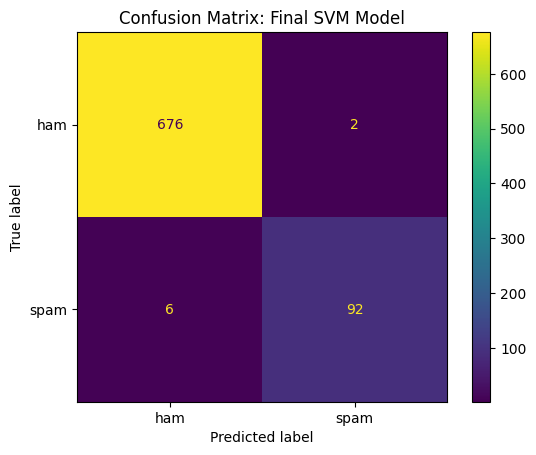

In [93]:
# Plot confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham", "spam"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix: Final SVM Model")
plt.show()

The confusion matrix shows that the final SVM model correctly classified 676 ham messages and 92 spam messages in the test set.

The model produced only 2 false positives, meaning 2 ham messages were incorrectly flagged as spam. It produced 6 false negatives, meaning 6 spam messages were missed and classified as ham.

For this task, the false negatives are especially important because they represent spam messages that would reach the user. However, the low number of false positives is also valuable because it means the model rarely blocks legitimate messages.

Create predictions dataframe

In [94]:
# Create a test predictions dataframe for error analysis and later saving

svm_predictions_df = test_df.copy()

svm_predictions_df["predicted_label_binary"] = test_pred
svm_predictions_df["predicted_label"] = svm_predictions_df["predicted_label_binary"].map({
    0: "ham",
    1: "spam"
})

svm_predictions_df["decision_score"] = test_scores

# Add a column showing whether the prediction was correct
svm_predictions_df["correct"] = (
    svm_predictions_df["label_binary"] == svm_predictions_df["predicted_label_binary"]
)

svm_predictions_df.head()

,label,text,label_binary,predicted_label_binary,predicted_label,decision_score,correct
0,ham,On the way to office da..,0,0,ham,-1.105529,True
1,ham,Pls give her prometazine syrup. 5mls then &lt...,0,0,ham,-1.651045,True
2,spam,Money i have won wining number 946 wot do i do...,1,0,ham,-0.866754,False
3,spam,"Dear Voucher Holder, 2 claim this weeks offer,...",1,1,spam,1.760505,True
4,ham,Today iZ Yellow rose day. If u love my frndshi...,0,0,ham,-0.954905,True


In [95]:
# Check how many predictions were correct and incorrect

prediction_summary = svm_predictions_df["correct"].value_counts().rename(index={
    True: "Correct",
    False: "Incorrect"
})

prediction_summary

,count
correct,
Correct,768
Incorrect,8


## Test evaluation summary

Overall, the final SVM model performed very strongly on the SMS spam classification task. The model achieved a high F1-score and ROC-AUC while remaining simpler and more interpretable than a transformer-based model.

The next section performs error analysis by inspecting false positives and false negatives. This helps identify what types of messages the SVM model still struggles with.

# 8. Error Analysis

This section inspects the messages that the final SVM model classified incorrectly.

The two main types of errors are:

- **False positives:** ham messages incorrectly predicted as spam
- **False negatives:** spam messages incorrectly predicted as ham

False negatives are particularly important for this task because they represent spam messages that the system failed to detect. False positives are also important because incorrectly filtering legitimate messages may reduce user trust.

In [96]:
# Separate incorrect predictions into false positives and false negatives

false_positives = svm_predictions_df[
    (svm_predictions_df["label_binary"] == 0) &
    (svm_predictions_df["predicted_label_binary"] == 1)
].copy()

false_negatives = svm_predictions_df[
    (svm_predictions_df["label_binary"] == 1) &
    (svm_predictions_df["predicted_label_binary"] == 0)
].copy()

print("Number of false positives:", len(false_positives))
print("Number of false negatives:", len(false_negatives))

Number of false positives: 2
Number of false negatives: 6


In [97]:
# Display false positives: ham messages predicted as spam

false_positives[[
    "label",
    "predicted_label",
    "decision_score",
    "text"
]]

,label,predicted_label,decision_score,text
575,ham,spam,0.121535,Your daily text from me – a favour this time
748,ham,spam,0.277578,I (Career Tel) have added u as a contact on IN...


In [98]:
# Display false negatives: spam messages predicted as ham

false_negatives[[
    "label",
    "predicted_label",
    "decision_score",
    "text"
]]

,label,predicted_label,decision_score,text
2,spam,ham,-0.866754,Money i have won wining number 946 wot do i do...
90,spam,ham,-0.307248,Burger King - Wanna play footy at a top stadiu...
134,spam,ham,-0.520911,Oh my god! I've found your number again! I'm s...
297,spam,ham,-0.136736,You can donate £2.50 to UNICEF's Asian Tsunami...
538,spam,ham,-0.430904,ringtoneking 84484
719,spam,ham,-0.846610,Hello. We need some posh birds and chaps to us...


The final SVM model made 8 errors on the test set: 2 false positives and 6 false negatives.

The false negatives show that the model mostly missed spam messages that were short, vague, or less similar to the most common prize/urgent-call spam patterns. For example, "ringtoneking 84484" is extremely short and gives the model very little context. Other missed spam messages, such as the Burger King promotion and the UNICEF donation message, look more like legitimate promotional or charity messages than obvious scams.

The false positives also make sense. Both ham messages contain spam-like surface features, such as references to "FREE SMS", contact platforms, or "daily text". These terms resemble common spam vocabulary, so the SVM incorrectly flagged them as spam.

Overall, the errors suggest that the SVM is very strong when messages contain clear lexical or character-level spam indicators, such as prize claims, premium numbers, URLs, or urgent wording. However, it can still struggle with ambiguous promotional messages, very short messages, or messages where the dataset label may not perfectly match modern expectations of harmful spam.

Some errors also reflect ambiguity in the dataset labels. For example, a UNICEF donation message is labelled as spam, but it may be better understood as an unsolicited promotional or donation message rather than a malicious scam. This shows that the dataset's binary ham/spam labels do not fully capture different levels of message harm.

In [99]:
# Create one combined error analysis dataframe

svm_errors_df = svm_predictions_df[
    svm_predictions_df["correct"] == False
].copy()

svm_errors_df["error_type"] = svm_errors_df.apply(
    lambda row: "false_positive" if row["label_binary"] == 0 else "false_negative",
    axis=1
)

svm_errors_df[[
    "error_type",
    "label",
    "predicted_label",
    "decision_score",
    "text"
]]

,error_type,label,predicted_label,decision_score,text
2,false_negative,spam,ham,-0.866754,Money i have won wining number 946 wot do i do...
90,false_negative,spam,ham,-0.307248,Burger King - Wanna play footy at a top stadiu...
134,false_negative,spam,ham,-0.520911,Oh my god! I've found your number again! I'm s...
297,false_negative,spam,ham,-0.136736,You can donate £2.50 to UNICEF's Asian Tsunami...
538,false_negative,spam,ham,-0.430904,ringtoneking 84484
575,false_positive,ham,spam,0.121535,Your daily text from me – a favour this time
719,false_negative,spam,ham,-0.846610,Hello. We need some posh birds and chaps to us...
748,false_positive,ham,spam,0.277578,I (Career Tel) have added u as a contact on IN...


In [100]:
# Sort incorrect predictions by absolute decision score
# Larger absolute values mean the model was more confident in its prediction.

svm_errors_df["absolute_decision_score"] = svm_errors_df["decision_score"].abs()

svm_errors_sorted = svm_errors_df.sort_values(
    by="absolute_decision_score",
    ascending=False
)

svm_errors_sorted[[
    "error_type",
    "label",
    "predicted_label",
    "decision_score",
    "absolute_decision_score",
    "text"
]]

,error_type,label,predicted_label,decision_score,absolute_decision_score,text
2,false_negative,spam,ham,-0.866754,0.866754,Money i have won wining number 946 wot do i do...
719,false_negative,spam,ham,-0.846610,0.846610,Hello. We need some posh birds and chaps to us...
134,false_negative,spam,ham,-0.520911,0.520911,Oh my god! I've found your number again! I'm s...
538,false_negative,spam,ham,-0.430904,0.430904,ringtoneking 84484
90,false_negative,spam,ham,-0.307248,0.307248,Burger King - Wanna play footy at a top stadiu...
748,false_positive,ham,spam,0.277578,0.277578,I (Career Tel) have added u as a contact on IN...
297,false_negative,spam,ham,-0.136736,0.136736,You can donate £2.50 to UNICEF's Asian Tsunami...
575,false_positive,ham,spam,0.121535,0.121535,Your daily text from me – a favour this time


## Error analysis summary

The error analysis shows that most SVM mistakes occur in ambiguous cases rather than obvious spam or obvious ham messages. The false negatives often contain fewer strong spam indicators, or they resemble legitimate promotions, charity messages, or normal conversational messages. The false positives contain words and structures that are common in spam messages, such as "FREE SMS" and action-oriented text.

This highlights a limitation of TF-IDF based SVM models: they are effective at learning repeated word and character patterns, but they do not deeply understand the intention or real-world trustworthiness of a message. As a result, messages that are promotional but not obviously malicious can be difficult to classify.

In a real-world SMS filtering system, this limitation could be addressed by adding extra features such as sender reputation, URL analysis, phone number metadata, user reports, or external scam databases. Within this project, the SVM still performs strongly, with only 8 errors out of 776 test messages.

# 9. Feature Importance

In [101]:
# Extract feature names from the final SVM model

feature_union = final_svm_model.named_steps["features"]
classifier = final_svm_model.named_steps["classifier"]

# Get word and character feature names separately
word_feature_names = feature_union.transformer_list[0][1].get_feature_names_out()
char_feature_names = feature_union.transformer_list[1][1].get_feature_names_out()

# Add prefixes so we can tell feature types apart
word_feature_names = ["word__" + feature for feature in word_feature_names]
char_feature_names = ["char__" + feature for feature in char_feature_names]

# Combine all feature names
all_feature_names = np.array(word_feature_names + char_feature_names)

# LinearSVC has one coefficient per feature for binary classification
coefficients = classifier.coef_[0]

print("Number of features:", len(all_feature_names))
print("Number of coefficients:", len(coefficients))

Number of features: 38059
Number of coefficients: 38059


Create a new dataframe to better organise and show the features and their relevent importance values

In [102]:
# Create a dataframe of features and their SVM coefficients

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefficients
})

feature_importance_df["feature_type"] = feature_importance_df["feature"].apply(
    lambda x: "word" if x.startswith("word__") else "character"
)

feature_importance_df.head()

,feature,coefficient,feature_type
0,word__00,0.207411,word
1,word__00 per,0.157230,word
2,word__00 sub,0.020919,word
3,word__000,0.164865,word
4,word__000 bonus,0.032044,word


In [103]:
# Features with the largest positive coefficients indicate spam

top_spam_features = feature_importance_df.sort_values(
    by="coefficient",
    ascending=False
).head(25)

top_spam_features

,feature,coefficient,feature_type
7783,word__txt,1.077578,word
1368,word__call,1.000847,word
6993,word__text,0.870034,word
8776,word__you have,0.805061,word
7819,word__uk,0.798639,word
6086,word__reply,0.742903,word
15296,char__090,0.740713,character
1580,word__chat,0.738903,word
6532,word__sms,0.738697,word
2637,word__free,0.716984,word


In [104]:
# Features with the most negative coefficients indicate ham

top_ham_features = feature_importance_df.sort_values(
    by="coefficient",
    ascending=True
).head(25)

top_ham_features

,feature,coefficient,feature_type
11278,char__ i,-0.740166,character
4853,word__my,-0.551497,word
4492,word__me,-0.498137,word
904,word__at,-0.407703,word
14362,char__..,-0.383349,character
14370,char__...,-0.343899,character
3859,word__its,-0.337144,word
3171,word__have you,-0.330767,word
4423,word__mail,-0.322611,word
5310,word__oh,-0.321951,word


In [105]:
# Combine top spam and ham features into one dataframe for later saving

top_features_df = pd.concat([
    top_spam_features.assign(direction="spam"),
    top_ham_features.assign(direction="ham")
])

top_features_df = top_features_df[[
    "direction",
    "feature_type",
    "feature",
    "coefficient"
]]

## Feature importance interpretation

The top spam-indicating features show that the SVM model learned patterns that are strongly associated with promotional or scam-like SMS messages. The strongest spam features include words such as `txt`, `call`, `text`, `reply`, `sms`, `free`, and `claim`. These are common in spam messages because they often ask users to respond, call a number, claim a prize, or interact with a paid service.

Several character-level features were also highly associated with spam, including `090`, `150p`, and `50p`. These features are important because many spam messages in the dataset contain premium-rate phone numbers or paid SMS charges. URL-related features such as `www`, `com`, `co uk`, and `wap` were also strong spam indicators, which suggests that the character and word n-gram features helped the model detect web-link and service-related patterns.

The top ham-indicating features were more conversational and personal, such as `my`, `me`, `oh`, `later`, `call me`, and emoticon-style patterns like `:)`. These features are more typical of ordinary person-to-person SMS messages.

Overall, the feature importance results support the design of the SVM model. Word-level TF-IDF features captured meaningful spam phrases, while character-level features captured shorter patterns such as phone numbers, paid-message costs, URLs, and abbreviations. This makes the SVM model more interpretable than the transformer model, because it is possible to inspect which features influenced the spam/ham decision.

# 10. Save Outputs

In [106]:
# Create a clean predictions dataframe for saving

svm_predictions_to_save = svm_predictions_df[[
    "label",
    "label_binary",
    "text",
    "predicted_label",
    "predicted_label_binary",
    "decision_score",
    "correct"
]].copy()

svm_predictions_to_save.head()

,label,label_binary,text,predicted_label,predicted_label_binary,decision_score,correct
0,ham,0,On the way to office da..,ham,0,-1.105529,True
1,ham,0,Pls give her prometazine syrup. 5mls then &lt...,ham,0,-1.651045,True
2,spam,1,Money i have won wining number 946 wot do i do...,ham,0,-0.866754,False
3,spam,1,"Dear Voucher Holder, 2 claim this weeks offer,...",spam,1,1.760505,True
4,ham,0,Today iZ Yellow rose day. If u love my frndshi...,ham,0,-0.954905,True


In [107]:
# Save useful SVM experiment outputs

metrics_path = RESULTS_DIR / "tfidf_svm_metrics.csv"
predictions_path = RESULTS_DIR / "tfidf_svm_predictions.csv"
top_features_path = RESULTS_DIR / "tfidf_svm_top_features.csv"

svm_metrics_df.to_csv(metrics_path, index=False)
svm_predictions_to_save.to_csv(predictions_path, index=False)
top_features_df.to_csv(top_features_path, index=False)

print("Saved metrics to:", metrics_path)
print("Saved predictions to:", predictions_path)
print("Saved top features to:", top_features_path)

Saved metrics to: results/tfidf_svm_metrics.csv
Saved predictions to: results/tfidf_svm_predictions.csv
Saved top features to: results/tfidf_svm_top_features.csv


Save the trained final model

In [108]:
# Save the trained SVM model

model_path = RESULTS_DIR / "tfidf_svm_model.joblib"

joblib.dump(final_svm_model, model_path)

print("Saved final SVM model to:", model_path)

Saved final SVM model to: results/tfidf_svm_model.joblib
